# IMPORT LIBRARIES

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization,Activation,Dropout)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# UPLOAD KAGGLE.JSON

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jussyanosama","key":"789a85375a8eae6bbb140353a968e031"}'}

# KAGGLE API SETUP

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# DOWNLOAD DATASET

In [ ]:
!kaggle datasets download -d lucasiturriago/oxfordiiitpet

Dataset URL: https://www.kaggle.com/datasets/lucasiturriago/oxfordiiitpet
License(s): MIT
100% 626M/626M [00:08<00:00, 78.2MB/s]



# UNZIP DATASET

In [ ]:
!unzip oxfordiiitpet.zip

Archive:  oxfordiiitpet.zip
  inflating: Test/masks/class_0/sample_0.png  
  inflating: Test/masks/class_0/sample_1.png  
  inflating: Test/masks/class_0/sample_10.png  
  inflating: Test/masks/class_0/sample_100.png  
  inflating: Test/masks/class_0/sample_101.png  
  inflating: Test/masks/class_0/sample_102.png  
  inflating: Test/masks/class_0/sample_103.png  
  inflating: Test/masks/class_0/sample_104.png  
  inflating: Test/masks/class_0/sample_105.png  
  inflating: Test/masks/class_0/sample_106.png  
  inflating: Test/masks/class_0/sample_107.png  
  inflating: Test/masks/class_0/sample_108.png  
  inflating: Test/masks/class_0/sample_109.png  
  inflating: Test/masks/class_0/sample_11.png  
  inflating: Test/masks/class_0/sample_110.png  
  inflating: Test/masks/class_0/sample_111.png  
  inflating: Test/masks/class_0/sample_112.png  
  inflating: Test/masks/class_0/sample_113.png  
  inflating: Test/masks/class_0/sample_114.png  
  inflating: Test/masks/class_0/sample_115.png 

# PATHS

In [ ]:
train_img= "/content/Train/patches"
train_mask= "/content/Train/masks/class_0"

val_img= "/content/Valid/patches"
val_mask= "/content/Valid/masks/class_0"

test_img= "/content/Test/patches"
test_mask= "/content/Test/masks/class_0"

# LOAD DATA

In [ ]:
# IMAGE SIZE

IMG_SIZE=256

def load_data(img_dir, mask_dir):

    images=[]
    masks=[]

    files=os.listdir(img_dir)

    for file in files:

        img_path=os.path.join(img_dir, file)
        mask_path=os.path.join(mask_dir, file)

        img=cv2.imread(img_path)
        mask=cv2.imread(mask_path, 0)

        if img is None or mask is None:
            continue

        # IMAGE
        img=cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img=img/255.0

        # MASK
        mask=cv2.resize(
            mask,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        mask=mask/255.0

        # BINARY
        mask=(mask>0.5).astype(np.float32)
        mask=np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# LOAD DATASETS

In [ ]:
X_train, y_train=load_data(train_img, train_mask)
X_val, y_val=load_data(val_img, val_mask)
X_test, y_test=load_data(test_img, test_mask)

print(X_train.shape)
print(y_train.shape)

(1024, 256, 256, 3)
(1024, 256, 256, 1)


# CHECK MASK VALUES

In [ ]:
print(np.unique(y_train[0]))

[0. 1.]


# SHOW SAMPLE DATA

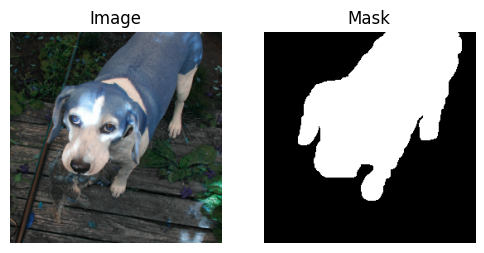

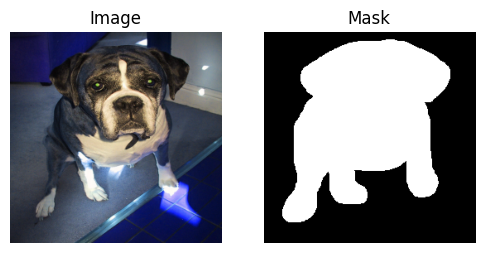

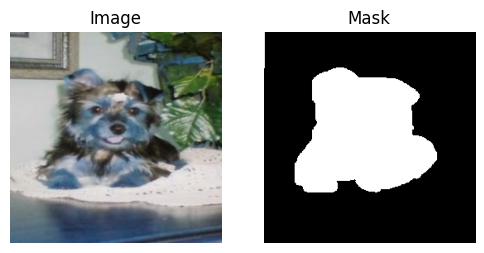

In [ ]:
def show_samples(X, y, n=3):

    for i in range(n):

        plt.figure(figsize=(6,3))

        # IMAGE
        plt.subplot(1,2,1)
        plt.imshow(X[i])
        plt.title("Image")
        plt.axis('off')

        # MASK
        plt.subplot(1,2,2)
        plt.imshow(y[i].squeeze(), cmap='gray')
        plt.title("Mask")
        plt.axis('off')

        plt.show()

show_samples(X_train, y_train)

# DATA AUGMENTATION

In [ ]:
datagen=ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

seed=42

img_gen=datagen.flow(
    X_train,
    batch_size=8,
    seed=seed
)

mask_gen=datagen.flow(
    y_train,
    batch_size=8,
    seed=seed
)

# TRAIN GENERATOR

In [ ]:
def train_gen():

    while True:
        imgs=next(img_gen)
        masks=next(mask_gen)
        masks=(masks>0.5).astype(np.float32)
        yield imgs, masks

train_generator=train_gen()

# SHOW AUGMENTED DATA

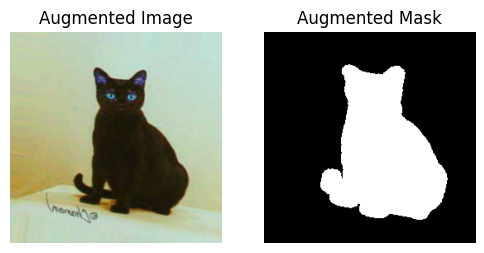

In [ ]:
x_aug, y_aug=next(train_generator)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x_aug[0])
plt.title("Augmented Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(y_aug[0].squeeze(), cmap='gray')
plt.title("Augmented Mask")
plt.axis('off')

plt.show()

# CONV BLOCK

In [ ]:
def conv_block(inputs, filters):

    x=Conv2D(filters, 3, padding='same')(inputs)
    x=BatchNormalization()(x)
    x=Activation('relu')(x)

    x=Conv2D(filters, 3, padding='same')(x)
    x=BatchNormalization()(x)
    x=Activation('relu')(x)

    return x

# U-NET + PRETRAINED ENCODER

In [ ]:
def build_unet():

    # PRETRAINED ENCODER
    encoder=MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # SKIP CONNECTIONS
    s1=encoder.get_layer("block_1_expand_relu").output

    s2=encoder.get_layer("block_3_expand_relu").output

    s3=encoder.get_layer("block_6_expand_relu").output

    s4=encoder.get_layer("block_13_expand_relu").output

    # BOTTLENECK
    b1=encoder.get_layer("block_16_project").output

    # DECODER
    u1=Conv2DTranspose(512,2,strides=2,padding='same')(b1)
    u1=concatenate([u1, s4])
    c1=conv_block(u1, 512)

    u2=Conv2DTranspose(256,2,strides=2,padding='same')(c1)
    u2=concatenate([u2, s3])
    c2=conv_block(u2, 256)

    u3=Conv2DTranspose(128,2,strides=2,padding='same')(c2)
    u3=concatenate([u3, s2])
    c3=conv_block(u3, 128)

    u4=Conv2DTranspose(64,2,strides=2,padding='same')(c3)
    u4=concatenate([u4, s1])
    c4=conv_block(u4, 64)

    # EXTRA UPSAMPLE
    u5=Conv2DTranspose(32,2,strides=2,padding='same')(c4)
    c5=conv_block(u5, 32)

    # OUTPUT
    outputs=Conv2D(1,1,activation='sigmoid')(c5)
    model=Model(
        encoder.input,
        outputs
    )

    return model

# DICE COEFFICIENT

In [ ]:
def dice_coef(y_true, y_pred):

    smooth=1e-6

    y_true_f=tf.reshape(y_true, [-1])
    y_pred_f=tf.reshape(y_pred, [-1])

    intersection=tf.reduce_sum(y_true_f * y_pred_f)

    return (
        (2. * intersection + smooth)/(tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)
    )

# DICE LOSS

In [ ]:
def dice_loss(y_true, y_pred):

    return 1-dice_coef(y_true, y_pred)

# BCE + DICE LOSS

In [ ]:
bce=tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):

    return (
        bce(y_true, y_pred)+dice_loss(y_true, y_pred)
    )

# BUILD MODEL

In [ ]:
model=build_unet()

/tmp/ipykernel_12626/747882257.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder=MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# COMPILE MODEL

In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss=combined_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 12,807,681 (48.86 MB)

 Trainable params: 12,772,801 (48.72 MB)

 Non-trainable params: 34,880 (136.25 KB)

# CALLBACKS

In [ ]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint=ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# TRAIN MODEL

In [ ]:
history=model.fit(
    train_generator,
    steps_per_epoch=len(X_train)//8,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - dice_coef: 0.6156 - loss: 0.8573
Epoch 1: val_loss improved from None to 0.41769, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 186s 618ms/step - dice_coef: 0.7510 - loss: 0.5683 - val_dice_coef: 0.8438 - val_loss: 0.4177
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coef: 0.8589 - loss: 0.3462
Epoch 2: val_loss improved from 0.41769 to 0.28557, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - dice_coef: 0.8688 - loss: 0.3263 - val_dice_coef: 0.8902 - val_loss: 0.2856
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coef: 0.8780 - loss: 0.3003
Epoch 3: val_loss improved from 0.28557 to 0.25130, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 36s 284ms/step - dice_coef: 0.8831 - loss: 0.293

# PLOT LOSS

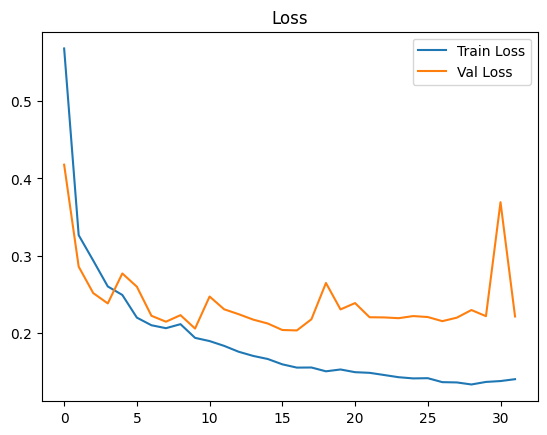

In [ ]:
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

# PLOT DICE SCORE

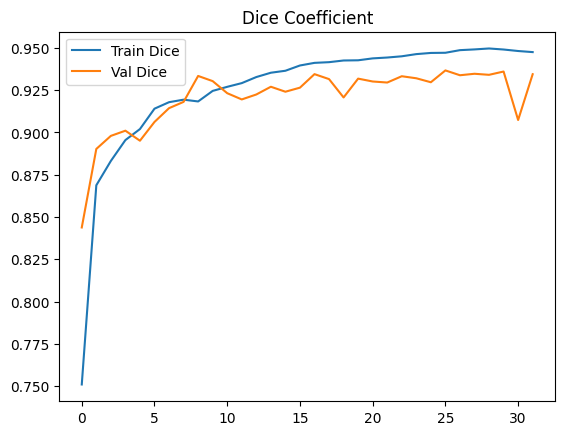

In [ ]:
plt.plot(history.history['dice_coef'],label='Train Dice')
plt.plot(history.history['val_dice_coef'],label='Val Dice')
plt.legend()
plt.title("Dice Coefficient")

plt.show()

# LOAD BEST MODEL

In [ ]:
model=load_model(
    "best_model.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_loss": dice_loss}
)

# PREDICTIONS

In [ ]:
pred=model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step


# THRESHOLD

In [ ]:
pred_binary=(pred>0.6).astype(np.float32)

# REMOVE NOISE

In [ ]:
def clean_mask(mask):

    kernel=np.ones((3,3), np.uint8)
    cleaned=cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_OPEN,
        kernel
    )

    return cleaned

# SHOW RESULTS

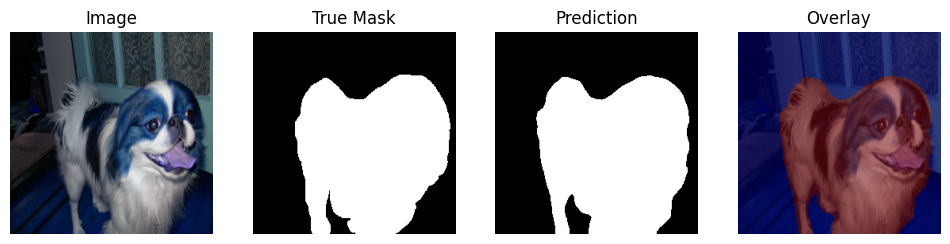

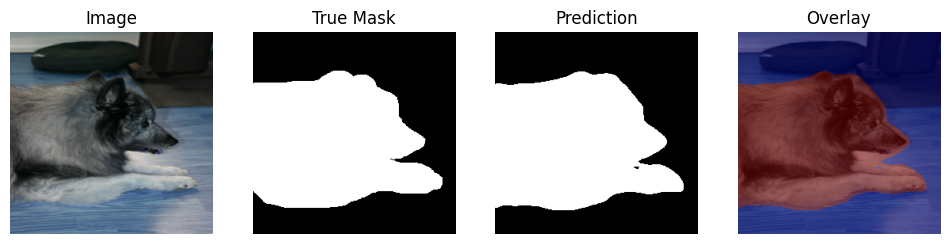

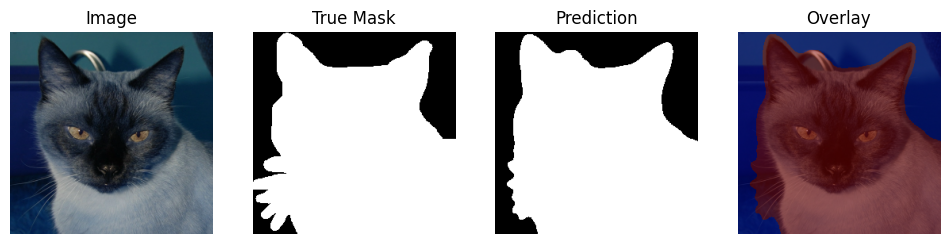

In [ ]:
def show_result(X,y_true,y_pred,index):

    pred_mask=clean_mask(y_pred[index].squeeze())
    plt.figure(figsize=(12,4))

    # IMAGE
    plt.subplot(1,4,1)
    plt.imshow(X[index])
    plt.title("Image")
    plt.axis('off')

    # TRUE MASK
    plt.subplot(1,4,2)
    plt.imshow(y_true[index].squeeze(),cmap='gray')
    plt.title("True Mask")
    plt.axis('off')

    # PREDICTION
    plt.subplot(1,4,3)
    plt.imshow(pred_mask,cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    # OVERLAY
    plt.subplot(1,4,4)
    plt.imshow(X[index])
    plt.imshow(pred_mask,cmap='jet',alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

# TEST RESULTS
show_result(X_test, y_test, pred_binary, 0)
show_result(X_test, y_test, pred_binary, 1)
show_result(X_test, y_test, pred_binary, 2)

# SAVE MODEL

In [ ]:
model.save("semantic_segmentation_model.keras")